# Homework 5

Avg reward: 0.506756 | Ewma reward: 0.528217: 100%|█| 200/200 [00:06<00:00, 31.7
Avg reward: 0.491282 | Ewma reward: 0.514743: 100%|█| 200/200 [00:06<00:00, 31.4
Avg reward: 0.480420 | Ewma reward: 0.504123: 100%|█| 200/200 [00:06<00:00, 29.7
Avg reward: 0.501680 | Ewma reward: 0.504996: 100%|█| 200/200 [00:06<00:00, 31.7
Avg reward: 0.509436 | Ewma reward: 0.536290: 100%|█| 200/200 [00:05<00:00, 33.5
Avg reward: 0.493772 | Ewma reward: 0.513371: 100%|█| 200/200 [00:06<00:00, 30.7
Avg reward: 0.493135 | Ewma reward: 0.504764: 100%|█| 200/200 [00:06<00:00, 30.4
Avg reward: 0.494884 | Ewma reward: 0.524726: 100%|█| 200/200 [00:06<00:00, 32.7
Avg reward: 0.506063 | Ewma reward: 0.524909: 100%|█| 200/200 [00:05<00:00, 35.5
Avg reward: 0.496909 | Ewma reward: 0.513002: 100%|█| 200/200 [00:05<00:00, 33.8


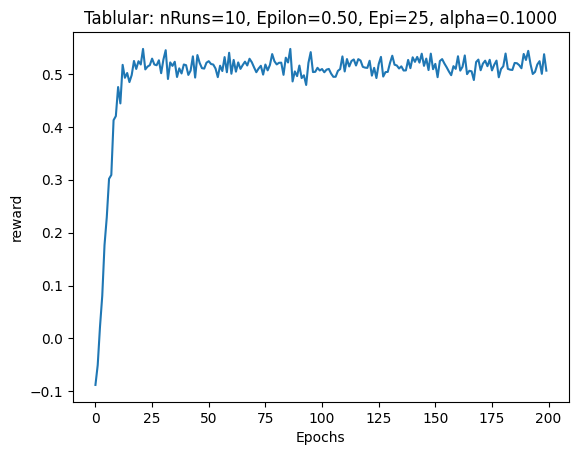

In [5]:
"""Tabular QL agent"""
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import framework
import utils

DEBUG = False

GAMMA = 0.5  # discounted factor
TRAINING_EP = 0.5  # epsilon-greedy parameter for training
TESTING_EP = 0.05  # epsilon-greedy parameter for testing
NUM_RUNS = 10
NUM_EPOCHS = 200
NUM_EPIS_TRAIN = 25  # number of episodes for training at each epoch
NUM_EPIS_TEST = 50  # number of episodes for testing
ALPHA = 0.1  # learning rate for training

ACTIONS = framework.get_actions()
OBJECTS = framework.get_objects()
NUM_ACTIONS = len(ACTIONS)
NUM_OBJECTS = len(OBJECTS)


# pragma: coderesponse template
def epsilon_greedy(state_1, state_2, q_func, epsilon):
    """Returns an action selected by an epsilon-Greedy exploration policy

    Args:
        state_1, state_2 (int, int): two indices describing the current state
        q_func (np.ndarray): current Q-function
        epsilon (float): the probability of choosing a random command

    Returns:
        (int, int): the indices describing the action/object to take
    """
    # TODO Your code here
    # Explore: choose a random action-object pair with probability epsilon
    if np.random.random() < epsilon:
        action_index = np.random.randint(NUM_ACTIONS)
        object_index = np.random.randint(NUM_OBJECTS)
    else:
        # Exploit: choose the action-object pair with the largest current Q-value
        # q_func[state_1, state_2, :, :] has shape (NUM_ACTIONS, NUM_OBJECTS).
        best_flat_index = np.argmax(q_func[state_1, state_2, :, :])
        action_index, object_index = np.unravel_index(
            best_flat_index, (NUM_ACTIONS, NUM_OBJECTS)
        )

    return (action_index, object_index)


# pragma: coderesponse end


# pragma: coderesponse template
def tabular_q_learning(q_func, current_state_1, current_state_2, action_index,
                       object_index, reward, next_state_1, next_state_2,
                       terminal):
    """Update q_func for a given transition

    Args:
        q_func (np.ndarray): current Q-function
        current_state_1, current_state_2 (int, int): two indices describing the current state
        action_index (int): index of the current action
        object_index (int): index of the current object
        reward (float): the immediate reward the agent recieves from playing current command
        next_state_1, next_state_2 (int, int): two indices describing the next state
        terminal (bool): True if this episode is over

    Returns:
        None
    """
    # TODO Your code here
    # Current Q-value: Q(s, a)
    current_q = q_func[current_state_1, current_state_2, action_index, object_index]

    # If the next state is terminal, there is no future reward term.
    if terminal:
        best_next_q = 0
    else:
        best_next_q = np.max(q_func[next_state_1, next_state_2, :, :])

    # Q-learning target: r + gamma * max_a' Q(s', a')
    td_target = reward + GAMMA * best_next_q

    # Q-learning update
    q_func[current_state_1, current_state_2, action_index, object_index] = (
        current_q + ALPHA * (td_target - current_q)
    )

    return None  # This function shouldn't return anything


# pragma: coderesponse end


# pragma: coderesponse template
def run_episode(for_training):
    """ Runs one episode
    If for training, update Q function
    If for testing, computes and return cumulative discounted reward

    Args:
        for_training (bool): True if for training

    Returns:
        None
    """
    epsilon = TRAINING_EP if for_training else TESTING_EP

    epi_reward = 0
    discount = 1

    # initialize for each episode
    (current_room_desc, current_quest_desc, terminal) = framework.newGame()
    current_state_1 = dict_room_desc[current_room_desc]
    current_state_2 = dict_quest_desc[current_quest_desc]

    while not terminal:
        # Choose next action using epsilon-greedy policy
        # TODO Your code here
        action_index, object_index = epsilon_greedy(
            current_state_1, current_state_2, q_func, epsilon
        )

        # Execute the selected action-object command in the game
        (next_room_desc, next_quest_desc, reward, terminal) = framework.step_game(
            current_room_desc, current_quest_desc, action_index, object_index
        )

        next_state_1 = dict_room_desc[next_room_desc]
        next_state_2 = dict_quest_desc[next_quest_desc]

        if for_training:
            # update Q-function.
            # TODO Your code here
            tabular_q_learning(
                q_func,
                current_state_1, current_state_2,
                action_index, object_index,
                reward,
                next_state_1, next_state_2,
                terminal
            )

        if not for_training:
            # update cumulative discounted reward
            # TODO Your code here
            epi_reward += discount * reward
            discount *= GAMMA

        # prepare next step
        current_room_desc = next_room_desc
        current_quest_desc = next_quest_desc
        current_state_1 = next_state_1
        current_state_2 = next_state_2

    if not for_training:
        return epi_reward


# pragma: coderesponse end


def run_epoch():
    """Runs one epoch and returns reward averaged over test episodes"""
    rewards = []

    for _ in range(NUM_EPIS_TRAIN):
        run_episode(for_training=True)

    for _ in range(NUM_EPIS_TEST):
        rewards.append(run_episode(for_training=False))

    return np.mean(np.array(rewards))


def run():
    """Returns array of test reward per epoch for one run"""
    global q_func
    q_func = np.zeros((NUM_ROOM_DESC, NUM_QUESTS, NUM_ACTIONS, NUM_OBJECTS))

    single_run_epoch_rewards_test = []
    pbar = tqdm(range(NUM_EPOCHS), ncols=80)
    for _ in pbar:
        single_run_epoch_rewards_test.append(run_epoch())
        pbar.set_description(
            "Avg reward: {:0.6f} | Ewma reward: {:0.6f}".format(
                np.mean(single_run_epoch_rewards_test),
                utils.ewma(single_run_epoch_rewards_test)))
    return single_run_epoch_rewards_test


if __name__ == '__main__':
    # Data loading and build the dictionaries that use unique index for each state
    (dict_room_desc, dict_quest_desc) = framework.make_all_states_index()
    NUM_ROOM_DESC = len(dict_room_desc)
    NUM_QUESTS = len(dict_quest_desc)

    # set up the game
    framework.load_game_data()

    epoch_rewards_test = []  # shape NUM_RUNS * NUM_EPOCHS

    for _ in range(NUM_RUNS):
        epoch_rewards_test.append(run())

    epoch_rewards_test = np.array(epoch_rewards_test)

    x = np.arange(NUM_EPOCHS)
    fig, axis = plt.subplots()
    axis.plot(x, np.mean(epoch_rewards_test,
                         axis=0))  # plot reward per epoch averaged per run
    axis.set_xlabel('Epochs')
    axis.set_ylabel('reward')
    axis.set_title(('Tablular: nRuns=%d, Epilon=%.2f, Epi=%d, alpha=%.4f' %
                    (NUM_RUNS, TRAINING_EP, NUM_EPIS_TRAIN, ALPHA)))
    plt.show()


# Question 1
**Write a run episode function that takes a boolean argument (whether the episode is a training episode or not) and runs one episode. Note: You should implement this function locally first. Make sure you can achieve reasonable performance on the Home World game before submitting your code.**

I implemented run_episode so that it runs one full episode. During training it updates the Q-function, and during testing it returns the cumulative discounted reward.

# Question 2
**Report performance. In your Q-learning algorithm, initialize Q at zero. Set NUM_RUNS =10, NUM_EPIS_TRAIN =25, NUM_EPIS_TEST=50, ϵ=0.5, TRAINING_EP=0.5, TESTING_EP=0.05 and the learning rate α=0.1. What is the number of epochs when the learning algorithm converges? (That is, the testing performance become stable)**

The Q-learning algorithm seems to convergence around 15-20 epochs as seen in the plot above. The average testing reward becomes stable approximately around 0.50 to 0.53. After convergence, the reward oscillates slightly due to the stochastic nature of ϵ-greedy exploration and random initial conditions

# Question 3
**What is the average episodic rewards of your Q-learning algorithm when it converges?**

After convergence, the testing reward remains relatively stable around 0.50 to 0.53 with an average value around 0.52

# Question 4
**Impact of ϵ on the convergence of Q-learning algorithm). Which of the behaviors below do you observe from running the algorithm?**

- For very large ϵ (say ϵ = 1) the algorithm converges slower compared to ϵ = 0.5.

- For very large ϵ (say ϵ = 1) the algorithm converges faster compared to ϵ = 0.5.

- For very small ϵ (say ϵ = 0.000001) the algorithm converges slower compared to ϵ = 0.5.

- For very small ϵ (say ϵ = 0.000001) the algorithm converges faster compared to ϵ = 0.5.

From the experimental plots, ϵ = 0.5 converged around 17 epochs, ϵ = 0.000001 converged around 15 epochs, and ϵ = 1.0 converged around 35 epochs. Therefore, the algorithm converged slower for very large ϵ compared to ϵ = 0.5, while the very small ϵ converged slightly faster than ϵ = 0.5 in this experiment. However, this does not necessarily mean it is always better, because very small ε has almost no exploration and may depend heavily on the initial Q-values and random run conditions.

# Question 5

**Effects of α). Fix the exploration parameter ϵ = 0.5 and do the experiments with different values of the training α ∈ [10−6, 1]. What do you observe?**

- The algorithm converges for all values of α in less than 200 epochs.

- The algorithm does not converge for all values of α in less than 200 epochs.

- The smaller the α the faster the convergence.

- The smaller the α the slower the convergence.

| α | Converge Epoch |
|---|---|
| 0.000001 | 16 |
| 0.0001 | 130 |
| 0.001 | 20 |
| 0.01 | 15 |
| 0.1 | 15 |
| 0.5 | 16 |
| 1 | 15 |

This results show that the Q-learning algorithm converged for all tested values of α within 200 epochs, but smaller values of α generally caused slower convergence such as α = 0.0001 required the most epochs to converge around 130 while larger values of α converfed much faster, around 15-16 epochs. This shows that larger learning rates allow the Q-values to update more quickly, whereas very small learning rates make the learning process much slower because each update changes the Q-values only by a small amount